# SimCLR

In [1]:
# import libraries
from tqdm import tqdm
import numpy as np
import torch
from torch.utils import data

from pathlib import Path

from utils.preprocess import preprocess
from utils.dataset import FFDdataset
from utils.model import Net
from utils.loss import ContrastiveLoss

import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import torchvision


## Preprocess Dataset

In [2]:
# preprocess object detection dataset
# preprocess()

## DataLoader

In [3]:
# dataset path

root_dir = Path("dataset/proc/")

train_dataset_path = Path("dataset/proc/train/train.txt")
valid_dataset_path = Path("dataset/proc/valid/valid.txt")

train_dataset = FFDdataset(train_dataset_path, root_dir, 'train')
valid_dataset = FFDdataset(valid_dataset_path, root_dir, 'valid')

train_loader = data.DataLoader(train_dataset, batch_size=20, num_workers=0, shuffle=True, drop_last=True)
valid_loader = data.DataLoader(valid_dataset, batch_size=20, num_workers=0, shuffle=False, drop_last=True)


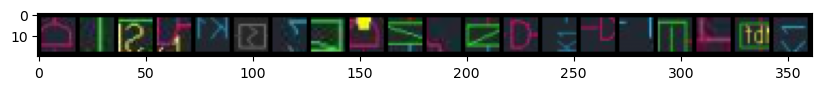

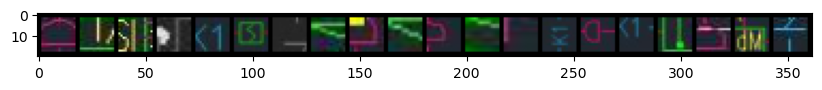

In [9]:

images1, images2, labels = next(iter(train_loader)) 

grid = torchvision.utils.make_grid(images1, nrow=20) 
grid2 = torchvision.utils.make_grid(images2, nrow=20)

grid_to_show = grid.permute(1, 2, 0).detach().cpu().numpy()
grid_to_show = np.clip(grid_to_show, 0, 1)

grid_to_show2 = grid2.permute(1, 2, 0).detach().cpu().numpy()
grid_to_show2 = np.clip(grid_to_show2, 0, 1)

# # Plot the grid
plt.figure(figsize=(10, 10))
plt.imshow(grid_to_show)
plt.figure(figsize=(10, 10))
plt.imshow(grid_to_show2)
plt.show()

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## Model Training

In [14]:
net = Net()
net.to(device)

optimizer = optim.SGD(net.parameters(), lr=0.002, momentum=0.9)
criterion = ContrastiveLoss()

train_loss = []
valid_loss = []

for epoch in tqdm(range(20)):
    net.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        
        input1, input2, labels = data
        
        input1 = input1.to(device)
        input2 = input2.to(device)
        
        optimizer.zero_grad()

        outputs1 = net(input1)
        outputs2 = net(input2)

        z1 = outputs1[0]
        z2 = outputs2[0]

        norm_z1 = F.normalize(z1, dim=1)
        norm_z2 = F.normalize(z2, dim=1)


        loss = criterion(norm_z1, norm_z2, device)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss.append(running_loss / len(train_loader.dataset))

    net.eval()
    v_loss = 0.0
    with torch.no_grad():
        for i, data in enumerate(valid_loader, 0):
            
            input1, input2, labels = data
        
            input1 = input1.to(device)
            input2 = input2.to(device)

            outputs1 = net(input1)
            outputs2 = net(input2)
    
            z1 = outputs1[0]
            z2 = outputs2[0]

            norm_z1 = F.normalize(z1, dim=1)
            norm_z2 = F.normalize(z2, dim=1)
    
    
            loss = criterion(norm_z1, norm_z2, device)

            v_loss += loss.item()
    valid_loss.append(v_loss / len(valid_loader.dataset))


100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:50<00:00,  2.54s/it]


## Result

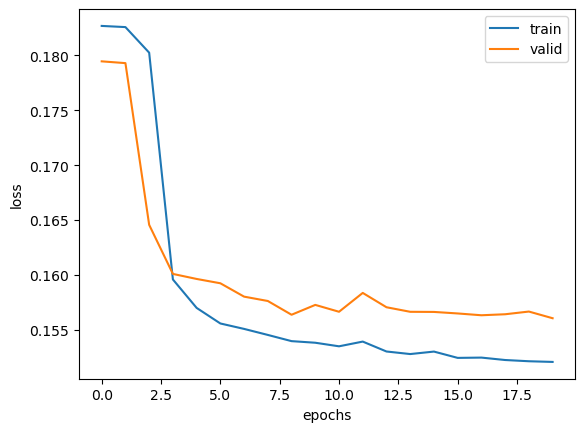

In [19]:
plt.plot(train_loss, label="train")
plt.plot(valid_loss, label="valid")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()